In [4]:
import numpy as np, itertools, os
import cupy as cp
import itertools
import matplotlib.pyplot as plt

from matplotlib.colors import LogNorm
from tqdm import tqdm
from scipy import stats
from scipy import signal

import astropy.units as u
import astropy.constants as cst

import finufft
import cufinufft  # this is finufft with GPUs
import cupy as cp

from astropy.io import fits
from astropy.cosmology import Planck18 as cosmo
from astropy.coordinates import EarthLocation, SkyCoord
from astropy.time import Time
from astropy.modeling.functional_models import AiryDisk2D

In [5]:
from utils_telescope.simulate_visibility import compute_visibility, get_baselines
from utils_telescope.utils_sky import gaussian_2d, galactic_synch_fg_custom

In [6]:
print('------ Define Telescope ------')
# Loading the telescope and station layout coords:
telescope_layout = np.loadtxt('./utils_telescope/skalow_AAstar_layout.txt') * u.m
station_layout = np.loadtxt('./utils_telescope/station_layout.txt') * u.m

N_ant = telescope_layout.shape[0]
N_B = int(N_ant*(N_ant-1)/2)

print(' number of stations:', N_ant)
print(' number of baselines:', N_B)

freq = 166. * u.MHz
lam = (cst.c / freq).to('m')
z = 1.42*u.GHz/freq - 1.
print(' frequency [MHz]:', freq)
print(' wavelength [m]:', lam)
print(' redshift:', z)

uv_coord, uv_length = get_baselines(N_ant=N_ant, wavelength=lam, layout=telescope_layout)

------ Define Telescope ------
 number of stations: 307
 number of baselines: 46971
 frequency [MHz]: 166.0 MHz
 wavelength [m]: 1.8059786626506023 m
 redshift: 7.554216867469879


Calculate baselines: 100%|█████████████| 46971/46971 [00:00<00:00, 59723.15it/s]


In [7]:
# Declination
dec = -30. * u.deg

# integration time
int_time = (10.*u.s).to('h')

# Radial angle, Hour angle window
h_angle = np.arange(-2, 2, int_time.value) * u.hourangle

time_steps = h_angle.size
t_obs = h_angle.max()-h_angle.min()

print('Observation length :', t_obs)
print('Integration time :', int_time.to('s'))
print('Number of time steps : ', time_steps)

Observation length : 3.997222222222208 hourangle
Integration time : 10.0 s
Number of time steps :  1440


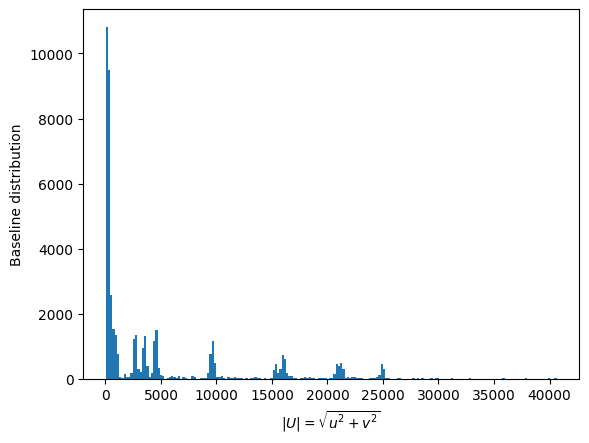

In [8]:
plt.hist(uv_length, bins=200);
plt.xlabel(r'$|U| = \sqrt{u^2 + v^2}$'), plt.ylabel('Baseline distribution')
plt.show()

In [33]:
print('------ Antenna Parameters ------')
D = np.linalg.norm(station_layout, axis=1).max()*2
print(' dish diameter [m]:', D)

theta_fwhm = (1.22 * lam / D) * u.rad #(1.03 * lam / D) * u.rad
theta_0 = np.sqrt(8*np.log(2)) * theta_fwhm #0.6 * theta_fwhm
V_0 = (np.pi * theta_0**2 / 2).to('sr')
N_pix = 512
print(' theta_fwhm:', theta_fwhm)
print(' theta_0:', theta_0)
print(' V_0:', V_0)

print('\n------ Observational Quantities ------')
FoV = np.sqrt(V_0).to('rad')
print(' FoV:', FoV.to('deg'))

#--------------------------------------------------
# define a 1D sky and get RA coordinate
thet = np.linspace(-FoV/2, FoV/2, N_pix).to('rad').value
dthet = np.diff(thet)[0] # rad
print(' dthet:', (dthet*u.rad).to('arcsec'))

# Create a grid of points (we ignore third dimension, i.e. n-axis)
l_coord, m_coord = np.meshgrid(thet, thet, indexing='ij')
lmn_coord = np.dstack((l_coord, m_coord)).reshape(-1, 2)

# Create a primary beam
def gauss_primary_beam(l, m, sigma):
    return np.exp(-((l**2 + m**2) / sigma**2))

def airy_primary_beam(l, m, radius):
    # here we assume is always pointing toward the phase center
    return AiryDisk2D().evaluate(x=l, y=m, amplitude=1, x_0=0, y_0=0, radius=radius)

#beam_pattern = gauss_primary_beam(l=l_coord, m=m_coord, sigma=theta_0.value)
beam_pattern = airy_primary_beam(l=l_coord, m=m_coord, radius=theta_fwhm.value)

------ Antenna Parameters ------
 dish diameter [m]: 38.06656275525806 m
 theta_fwhm: 0.05788003457520991 rad
 theta_0: 0.13629706562478872 rad
 V_0: 0.02918051072909773 sr

------ Observational Quantities ------
 FoV: 9.787439191027847 deg
 dthet: 68.9526048682983 arcsec


In [35]:
img = np.zeros((N_pix, N_pix), dtype=np.float_)

# position of the source outside the FoV
l_s, m_s = (3*u.deg).to('rad').value, (0.*u.deg).to('rad').value

# intensity of the point source
I_0 = 100.

phase = (uv_coord[:,0]*l_s + uv_coord[:,1]*m_s + uv_coord[:,2]*(np.sqrt(1 - l_s**2 - m_s**2) - 1))
fringe = np.exp(-2j * np.pi * phase)

beam_at_lsms = airy_primary_beam(l=l_s, m=m_s, radius=theta_fwhm.value)
#beam_at_lsms = gauss_primary_beam(l=l_s, m=m_s, sigma=theta_0.value)

vis = beam_at_lsms * I_0 * fringe

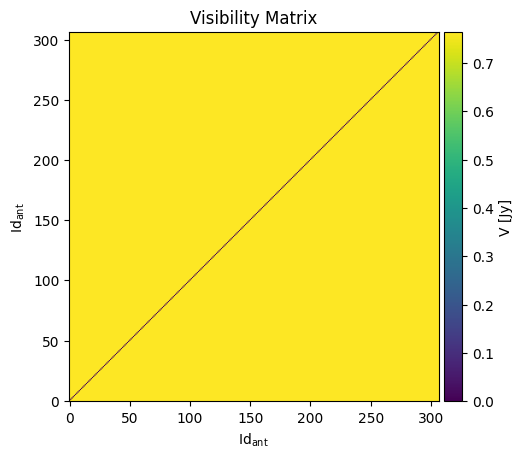

(None, None)

<Figure size 640x480 with 0 Axes>

In [36]:
# Define visibilities matrix
pair_comb_sort = list(itertools.combinations(range(N_ant), 2))

V_matrix = np.zeros((N_ant, N_ant))

for i_b in range(N_B):
    ii, jj = pair_comb_sort[i_b]

    # store visibility matrix
    V_matrix[ii, jj] = np.abs(vis[i_b])

# pairs are only for one corner
V_matrix = V_matrix + np.conj(V_matrix.T)

# plot visibility matrix
plt.title('Visibility Matrix')
im = plt.imshow(V_matrix, origin='lower', cmap='viridis')
plt.xlabel(r'Id$_\mathrm{ant}$'), plt.ylabel(r'Id$_\mathrm{ant}$')
plt.colorbar(im, label='V [Jy]', pad=0.01)
plt.show(), plt.clf()

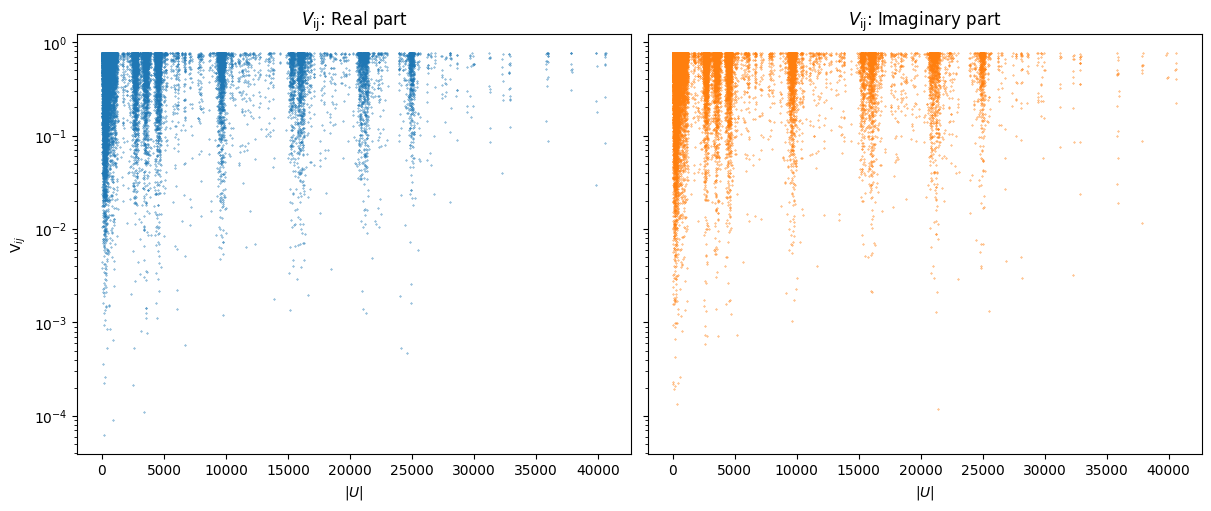

In [37]:
fig, axs = plt.subplots(figsize=(12, 5), ncols=2, nrows=1, constrained_layout=True, sharex=True, sharey=True)

axs[0].set_title(r'$V_\mathrm{ij}$: Real part')
axs[0].scatter(uv_length, vis.real, s=0.1, color='tab:blue')

axs[1].set_title(r'$V_\mathrm{ij}$: Imaginary part')
axs[1].scatter(uv_length, vis.imag, s=0.1, color='tab:orange');

for ax in axs:
    ax.set_xlabel(r'$|U|$')
    ax.set_yscale('log')

axs[0].set_ylabel(r'V$_{ij}$')
plt.show()

In [38]:
"""
u_bin = np.fft.fftshift(np.fft.fftfreq(N_pix+1, dthet))

# binn the visibility points (real and complex space)
uv_plane_real = stats.binned_statistic_2d(x=uv_coord[:,0], y=uv_coord[:,1], 
                                     values=vis.real, statistic='sum', bins=[u_bin, u_bin]).statistic
uv_plane_compl = stats.binned_statistic_2d(x=uv_coord[:,0], y=uv_coord[:,1], 
                                     values=vis.imag, statistic='sum', bins=[u_bin, u_bin]).statistic

# combine back the uv-data
uv_plane = uv_plane_real + 1j*uv_plane_compl

# sampling
uv_sampl = stats.binned_statistic_2d(x=uv_coord[:,0], y=uv_coord[:,1], 
                                     values=None, statistic='count', bins=[u_bin, u_bin]).statistic

uv_plane /= np.where(uv_sampl > 0, uv_sampl, 1)

bh_window = signal.windows.blackmanharris(N_pix)

# inverse fourier transform gridded visibility
I_sky_reconstruct = np.fft.ifft2(uv_plane)
I_sky_reconstruct = np.fft.fftshift(np.abs(I_sky_reconstruct))
"""

# here FINUFFT uses exp(i * k * x), not exp(2pi i u l)
u_coord = np.ascontiguousarray(2*np.pi * uv_coord[:, 0], dtype=np.float64)
v_coord = np.ascontiguousarray(2*np.pi * uv_coord[:, 1], dtype=np.float64)

u_bin = np.linspace(u_coord.min(), u_coord.max(), N_pix+1)

# use Non-Uniform FFT (NUFFT)
I_flat = finufft.nufft2d3(u_coord, v_coord, vis, l_coord.flatten(), m_coord.flatten(), isign=+1, eps=1e-6)

# this works but SKA-low uv-coord are too large to run on my laptop GPU
#I_flat = cufinufft.nufft2d3(cp.asarray(u_coord), cp.asarray(v_coord), cp.asarray(vis), cp.asarray(l_coord.flatten()), cp.asarray(m_coord.flatten()), isign=+1, eps=1e-6)

# move results off the GPU
#I_flat = cp.asnumpy(I_flat)

I_sky_reconstruct = np.abs(I_flat.reshape(N_pix, N_pix))

# Normalization(?)
#I_sky_reconstruct /= V_0.value # from Jy/beam to Jy

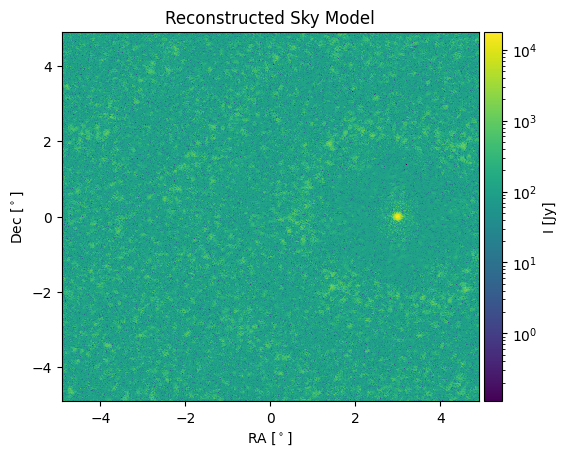

(None, None)

<Figure size 640x480 with 0 Axes>

In [40]:
# plot visibility matrix
plt.title('Reconstructed Sky Model')
im = plt.pcolormesh((l_coord*u.rad).to('deg').value, (m_coord*u.rad).to('deg').value, I_sky_reconstruct, cmap='viridis', norm='log')
plt.xlabel(r'RA [$^\circ$]'), plt.ylabel(r'Dec [$^\circ$]')
plt.colorbar(im, label='I [Jy]', pad=0.01)

#plt.xlim(200, 250), plt.ylim(100, 150)
#plt.xlim(3000, 3500), plt.ylim(1750, 1750+500)
plt.show(), plt.clf()

In [ ]:
fig, axs = plt.subplots(figsize=(12, 5), ncols=2, nrows=1, constrained_layout=True)
axs[0].set_title(r'$V_\mathrm{ij}$: Real part')
im = axs[0].pcolormesh(u_bin, u_bin, uv_plane.real, cmap='viridis', norm='log')
axs[0].set_xlabel(r'u'), axs[0].set_ylabel(r'v')
plt.colorbar(im, ax=axs[0], label='I [Jy]', pad=0.01)

axs[1].set_title(r'$V_\mathrm{ij}$: Imaginary part')
im = axs[1].pcolormesh(u_bin, u_bin, uv_plane.imag, cmap='viridis', norm='log')
axs[1].set_xlabel(r'u'), axs[1].set_ylabel(r'v')
plt.colorbar(im, ax=axs[1], label='I [Jy]', pad=0.01)
plt.show(), plt.clf()